# Cards Against Humanity: LLM Humor Alignment Analysis

This notebook analyzes a multi-LLM Cards Against Humanity tournament where **5 models** (GPT, Gemini, Claude, DeepSeek, Grok) each pick a white card to fill in a black card prompt. Each round has a human-selected **winner**. Every round is played **twice** (2 replicates), enabling us to study both alignment and consistency.

**Dataset:** ~9,900 records (4,947 unique rounds × 2 replicates), 5 models



In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
sns.set_theme(style="whitegrid")

# Load data
with open('/path/to/your/data.jsonl', 'r') as f:
    data = [json.loads(line) for line in f]

MODELS = ['gpt', 'gemini', 'claude', 'deepseek', 'grok']
MODEL_COLORS = {'gpt': '#10a37f', 'gemini': '#4285f4', 'claude': '#d97706', 
                'deepseek': '#7c3aed', 'grok': '#ef4444'}

n_total = len(data)
n_valid = sum(1 for r in data if r['round_valid'])
n_rounds = len(set(r['round_id'] for r in data))
n_reps = sorted(set(r['replicate'] for r in data))

print(f"Total records:      {n_total:,}")
print(f"Unique rounds:      {n_rounds:,}")
print(f"Replicates:         {n_reps}")
print(f"Valid records:       {n_valid:,} ({n_valid/n_total:.1%})")
print(f"Invalid records:     {n_total - n_valid:,} ({(n_total-n_valid)/n_total:.1%})")


Total records:      9,894
Unique rounds:      4,947
Replicates:         [1, 2]
Valid records:       9,612 (97.1%)
Invalid records:     282 (2.9%)


## 1. Data Preparation

We build two DataFrames:
- **`df`**: one row per model × round × replicate (flat, for per-replicate analysis)  
- **`rounds_df`**: grouped by round_id, with both replicates side by side (for consistency analysis)


In [ ]:
# Filter valid rounds
valid = [r for r in data if r['round_valid']]

# Flat dataframe: one row per (model, round, replicate)
records = []
for r in valid:
    winner = r['winners'][0] if r['winners'] else None
    for m in MODELS:
        pick = r['picks'].get(m)
        records.append({
            'round_id': r['round_id'],
            'replicate': r['replicate'],
            'black_card': r['black_card'],
            'white_cards': r['white_cards'],
            'model': m,
            'pick': pick,
            'winner': winner,
            'matched_winner': (pick == winner) if pick else False,
            'target_slot': r['target_slot'] if pick else None
        })
df = pd.DataFrame(records)

# Group replicates by round_id
by_round = defaultdict(dict)
for r in valid:
    by_round[r['round_id']][r['replicate']] = r

print(f"Flat dataframe: {len(df):,} rows")
print(f"Rounds with both valid replicates: {sum(1 for v in by_round.values() if len(v) == 2):,}")
print(f"Rounds with only 1 valid replicate: {sum(1 for v in by_round.values() if len(v) == 1):,}")
df.head()


## 2. Human Alignment: Win Rate

How often does each model pick the card that was selected as the round winner? We aggregate across **both replicates** (so a model gets two chances per round).


In [ ]:
import numpy as np
from scipy import stats

MODELS_LABELS = [m.capitalize() for m in MODELS]

def bootstrap_ci(data, n_boot=1000, ci=95, seed=42):
    rng = np.random.default_rng(seed)
    boot_means = [rng.choice(data, size=len(data), replace=True).mean()
                  for _ in range(n_boot)]
    lo = np.percentile(boot_means, (100 - ci) / 2)
    hi = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return lo, hi

model_stats = {}
for m in MODELS:
    data = df[df['model'] == m]['matched_winner'].values
    p = data.mean()
    lo, hi = bootstrap_ci(data)
    model_stats[m] = {'rate': p, 'n': len(data), 'lo': lo, 'hi': hi}

rates   = [model_stats[m]['rate'] for m in MODELS]
yerr_lo = [model_stats[m]['rate'] - model_stats[m]['lo'] for m in MODELS]
yerr_hi = [model_stats[m]['hi'] - model_stats[m]['rate'] for m in MODELS]

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(MODELS_LABELS, rates,
              color=[MODEL_COLORS[m] for m in MODELS],
              edgecolor='white', linewidth=1.5)
ax.errorbar(MODELS_LABELS, rates,
            yerr=[yerr_lo, yerr_hi],
            fmt='none', color='black', capsize=5, capthick=1.5, linewidth=1.5)
for bar, m in zip(bars, MODELS):
    ax.text(bar.get_x() + bar.get_width() / 2,
            model_stats[m]['hi'] + 0.005,
            f'{model_stats[m]["rate"]:.1%}',
            ha='center', va='bottom', fontweight='bold', fontsize=13)

ax.axhline(y=0.1, color='#222222', linestyle='--', linewidth=1.8,
           alpha=1.0, label='Random baseline (1/10)', zorder=5)
ax.set_ylabel('Win Rate')
ax.legend()
ax.set_ylim(0, max(rates) + 0.06)

plt.tight_layout()
#plt.savefig('overall_win_rate.pdf', bbox_inches='tight', dpi=300)
plt.show()

# Counts
for m in MODELS:
    s = model_stats[m]
    print(f"  {m:>10s}: {s['rate']:.2%}  (n={s['n']})  95% CI [{s['lo']:.2%}, {s['hi']:.2%}]")

## 3. Inter-Model Agreement


How often do two models pick the **same card** in the same round-replicate?


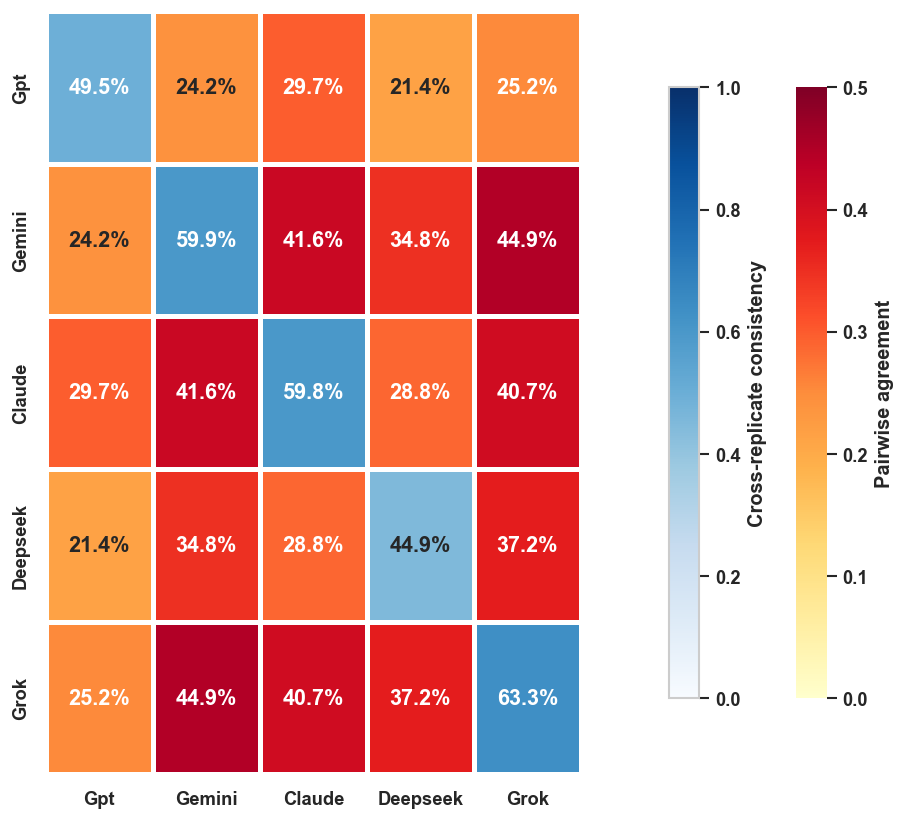

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cross-replicate consistency (diagonal)
consistency = {}
for m in MODELS:
    r1 = df[(df['model'] == m) & (df['replicate'] == 1)].set_index('round_id')['pick']
    r2 = df[(df['model'] == m) & (df['replicate'] == 2)].set_index('round_id')['pick']
    common = r1.index.intersection(r2.index)
    consistency[m] = (r1.loc[common] == r2.loc[common]).mean()

# Cross-replicate pairwise agreement (off-diagonal)
agreement = pd.DataFrame(index=MODELS, columns=MODELS, dtype=float)
for m1 in MODELS:
    for m2 in MODELS:
        if m1 == m2:
            agreement.loc[m1, m2] = consistency[m1]
        else:
            # r1 of m1 vs r2 of m2
            p1 = df[(df['model'] == m1) & (df['replicate'] == 1)].set_index('round_id')['pick']
            p2 = df[(df['model'] == m2) & (df['replicate'] == 2)].set_index('round_id')['pick']
            common = p1.index.intersection(p2.index)
            agr_12 = (p1.loc[common] == p2.loc[common]).mean()

            # r2 of m1 vs r1 of m2
            p1 = df[(df['model'] == m1) & (df['replicate'] == 2)].set_index('round_id')['pick']
            p2 = df[(df['model'] == m2) & (df['replicate'] == 1)].set_index('round_id')['pick']
            common = p1.index.intersection(p2.index)
            agr_21 = (p1.loc[common] == p2.loc[common]).mean()

            agreement.loc[m1, m2] = np.mean([agr_12, agr_21])

agreement = agreement.astype(float)

# Rename after filling
agreement.index   = MODELS_LABELS
agreement.columns = MODELS_LABELS

# Masks
mask_offdiag = ~np.eye(len(MODELS_LABELS), dtype=bool)
mask_diag    =  np.eye(len(MODELS_LABELS), dtype=bool)

fig, ax = plt.subplots(figsize=(8, 7))

# Off-diagonal: YlOrRd
sns.heatmap(agreement, annot=True, fmt='.1%', cmap='YlOrRd',
            vmin=0, vmax=0.5, linewidths=2, linecolor='white',
            mask=mask_diag, ax=ax,
            annot_kws={"fontsize": 13, "fontweight": "bold"},
            cbar_kws={"shrink": 0.8, "pad": 0.02, "label": "Pairwise agreement"})

# Diagonal: Blues
sns.heatmap(agreement, annot=True, fmt='.1%', cmap='Blues',
            vmin=0, vmax=1, linewidths=2, linecolor='white',
            mask=mask_offdiag, ax=ax,
            annot_kws={"fontsize": 13, "fontweight": "bold"},
            cbar=False)

# Manual colorbar for diagonal
sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.8, pad=0.12, label="Cross-replicate consistency")

plt.tight_layout()
plt.savefig('pairwise_agreement_revised_.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [141]:
import json

slate_lookup = {}
with open('outputs/matches_final.jsonl') as f:
    for line in f:
        row = json.loads(line)
        key = (row['round_id'], row['replicate'])
        slate_lookup[key] = row['white_cards']

In [142]:
def get_pick_position(row):
    key = (row['round_id'], row['replicate'])
    slate = slate_lookup.get(key, [])
    try:
        return slate.index(row['pick'])
    except ValueError:
        return None

df['pick_position'] = df.apply(get_pick_position, axis=1)

In [143]:
position_stats = {}
for m in MODELS:
    sub = df[df['model'] == m].dropna(subset=['pick_position'])
    counts = sub.groupby('pick_position')['pick_position'].count()
    position_stats[m] = counts / counts.sum()

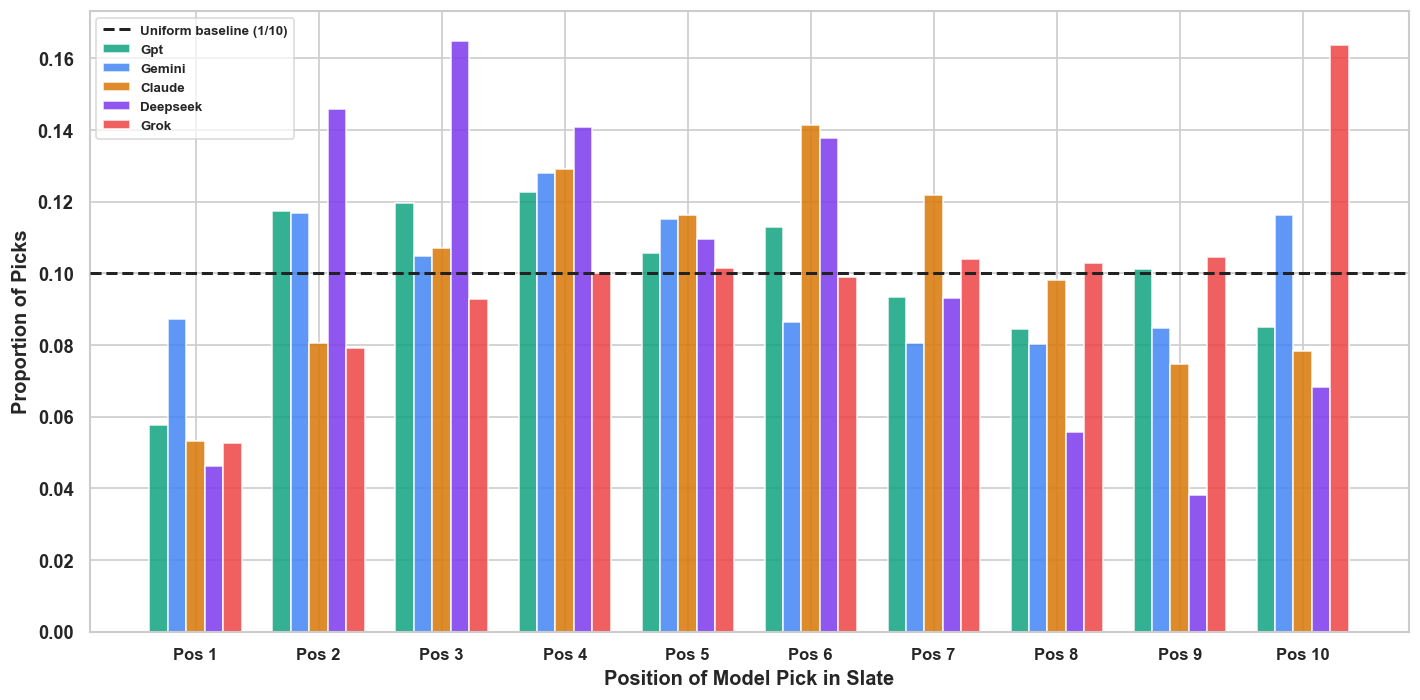

In [158]:
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(10)
w = 0.15

for i, m in enumerate(MODELS):
    vals = [position_stats[m].get(pos, 0) for pos in range(10)]
    ax.bar(x + i * w, vals, w, label=m.capitalize(),
           color=MODEL_COLORS[m], alpha=0.85, edgecolor='white')

#ax.axhline(y=0.1, color='gray', linestyle='--', alpha=0.4, label='Uniform baseline (1/10)')
ax.axhline(y=0.1, color='#222222', linestyle='--', linewidth=1.8,
           alpha=1.0, label='Uniform baseline (1/10)', zorder=5)
ax.set_xlabel('Position of Model Pick in Slate', fontsize=12, fontweight='bold')
ax.set_ylabel('Proportion of Picks', fontsize=12, fontweight='bold')
#ax.set_title('Position Bias: Where Do Models Pick From?', fontsize=13, fontweight='bold')
ax.set_xticks(x + w * (len(MODELS) - 1) / 2)
ax.set_xticklabels([f'Pos {i+1}' for i in range(10)], fontsize=10, fontweight='bold')
ax.legend(prop={'weight': 'bold', 'size': 8}, framealpha=0.7, borderpad=0.5)
plt.tight_layout()
plt.savefig('position_bias.pdf', bbox_inches='tight', dpi=300)
plt.show()

## 4. Round Validity & Model Failure Rates

Invalid rounds occur when a model fails to respond or gives an unparseable answer. Which models cause the most failures?


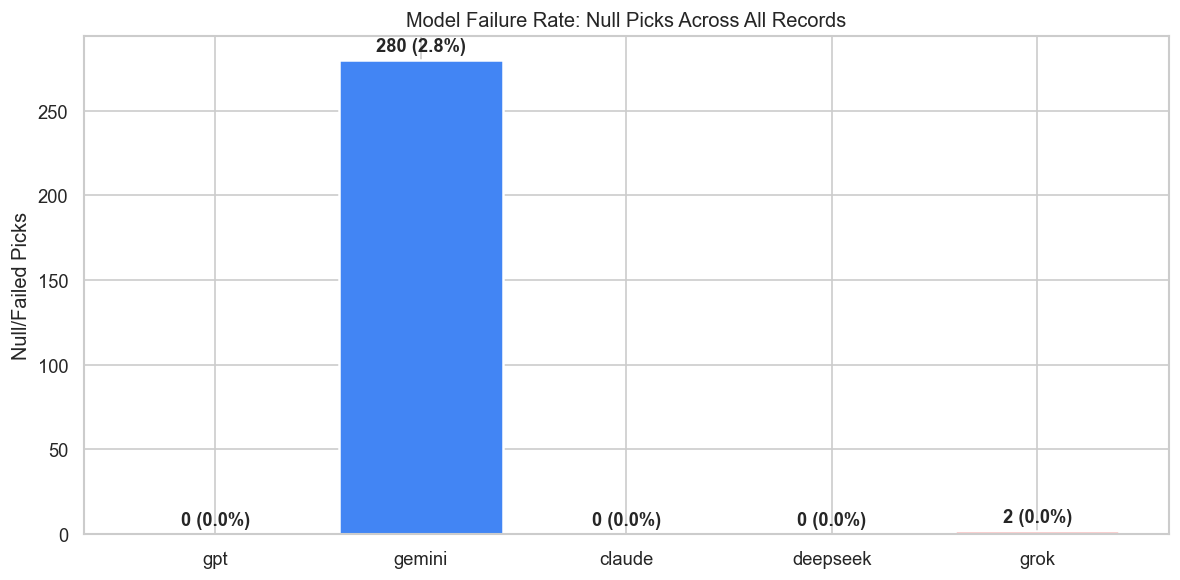

Total invalid records: 282 / 9894 (2.9%)


In [ ]:
# Analyze invalid rounds
invalid = [r for r in data if not r['round_valid']]

null_counts = {m: 0 for m in MODELS}
total_rounds = len(data)
for r in data:
    for m in MODELS:
        if r['picks'].get(m) is None:
            null_counts[m] += 1

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(MODELS, [null_counts[m] for m in MODELS], 
              color=[MODEL_COLORS[m] for m in MODELS], edgecolor='white', linewidth=1.5)
for bar, m in zip(bars, MODELS):
    v = null_counts[m]
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{v} ({v/total_rounds:.1%})', ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('Null/Failed Picks')
ax.set_title('Model Failure Rate: Null Picks Across All Records')
plt.tight_layout()
plt.show()

print(f"Total invalid records: {len(invalid)} / {total_rounds} ({len(invalid)/total_rounds:.1%})")
